In [ ]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "duckdb",
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-09-08T15:17:54.906812459+02:00"
# ///

# Analysing feature importance

- Loads a Parquet dataset with Polars, filters to a single year, and selects a fixed feature set plus `taxonomy_norm` (target) and `split`.
- Constructs train/valid/test from the `split` column; drops under-represented training classes based on a relative frequency threshold; applies the same class list to valid/test.
- Encodes labels with `LabelEncoder` fit on train and reused for valid/test; preserves `class_names`.
- Runs an Optuna study to tune an XGBoost multi-class classifier; optimization target is **macro-F1 on validation**; uses pruning and early stopping.
- Trains a final model with the best hyperparameters and records training/validation **mlogloss** histories.
- Evaluates on the test set and reports the **macro-F1** score.
- Computes SHAP values (`TreeExplainer`) on test predictions; aggregates per-class mean |SHAP| and derives macro and class-frequency-weighted feature importance profiles.
- Writes a single results JSON containing configuration (paths, year, threshold, seed), tuned `xgb_params`, dataset sizes, feature/class metadata, train/valid losses, test macro-F1, and feature importances (per-class, macro, weighted).
- Logs dataset shapes, removed classes, best trial value/params, and top features; optional debug mode increases verbosity.


In [2]:
import duckdb
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import json

In [3]:
data_path = Path("../results/feature_importance")

In [4]:
files = glob.glob(str(data_path / "results_*.json"))
data = {}
for file in files:
    with open(file, "r") as f:
        d = json.load(f)
        data[d['year']] = d

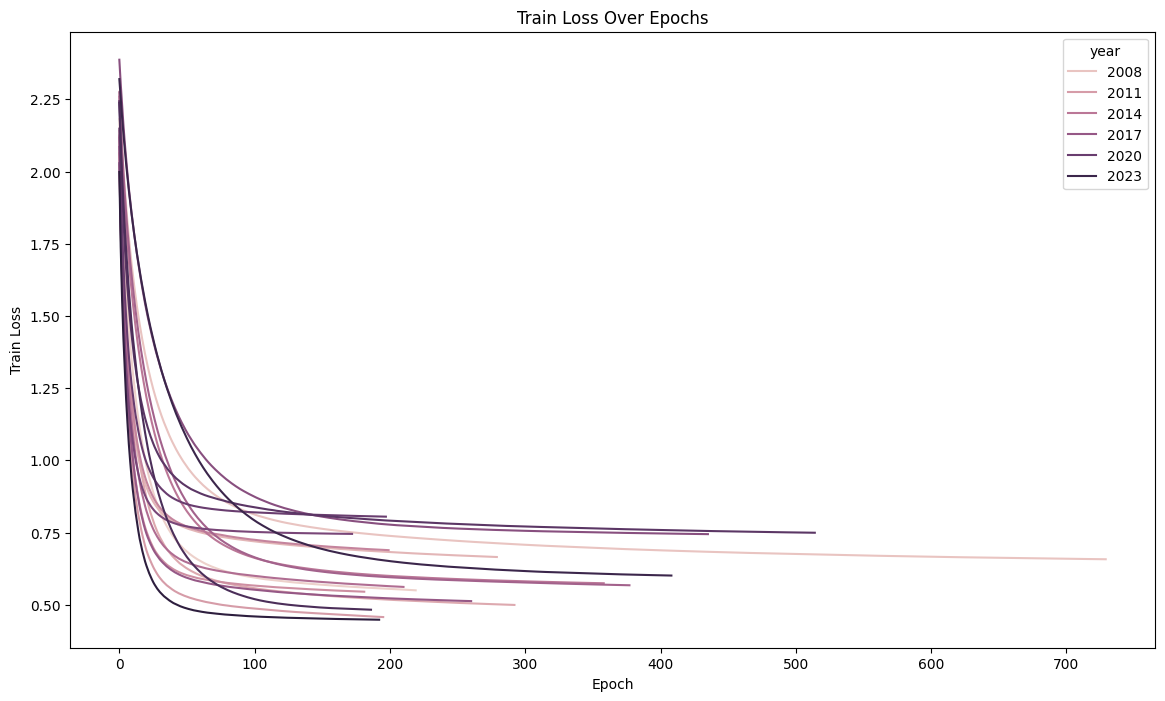

In [5]:
train_loss = pl.DataFrame({
    "year": [year for year in data for _ in range(len(data[year]["train_loss"]))],
    "epoch": [i for year in data for i in range(len(data[year]["train_loss"]))],
    "train_loss": [v for year in data for v in data[year]["train_loss"]],
})

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=train_loss.to_pandas(),
    x="epoch",
    y="train_loss",
    hue="year",
)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss Over Epochs")
plt.show()

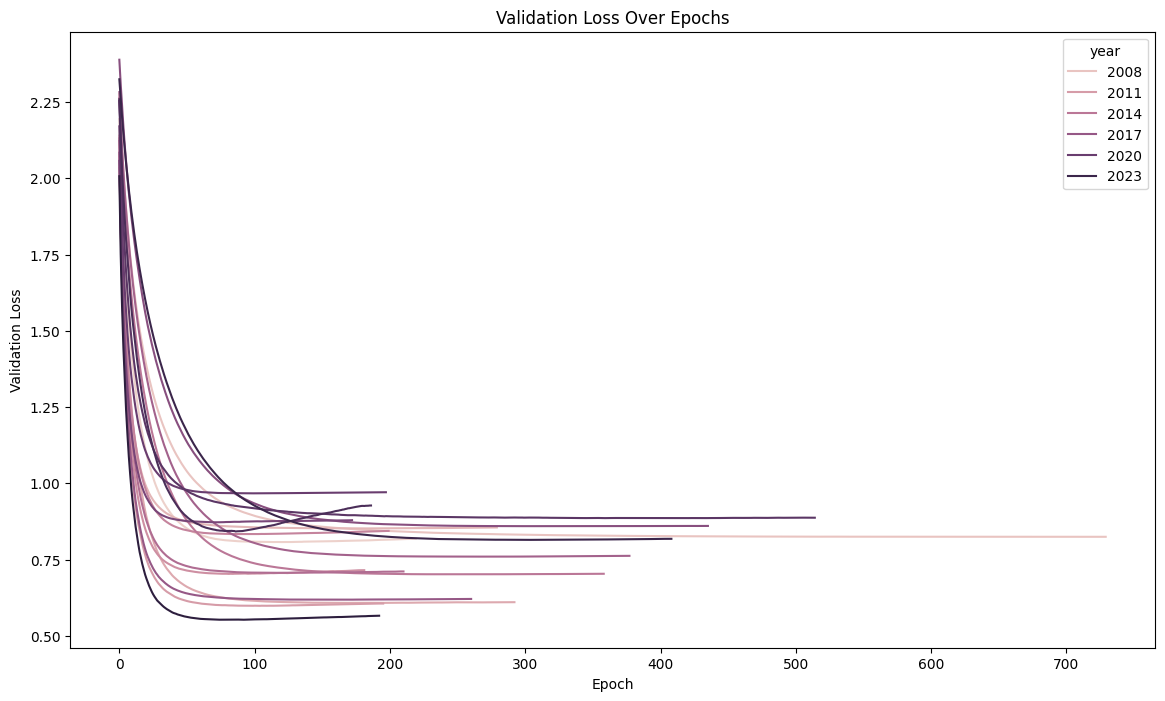

In [6]:
val_loss = pl.DataFrame({
    "year": [year for year in data for _ in range(len(data[year]["val_loss"]))],
    "epoch": [i for year in data for i in range(len(data[year]["val_loss"]))],
    "val_loss": [v for year in data for v in data[year]["val_loss"]],
})

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=val_loss.to_pandas(),
    x="epoch",
    y="val_loss",
    hue="year",
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Over Epochs")
plt.show()

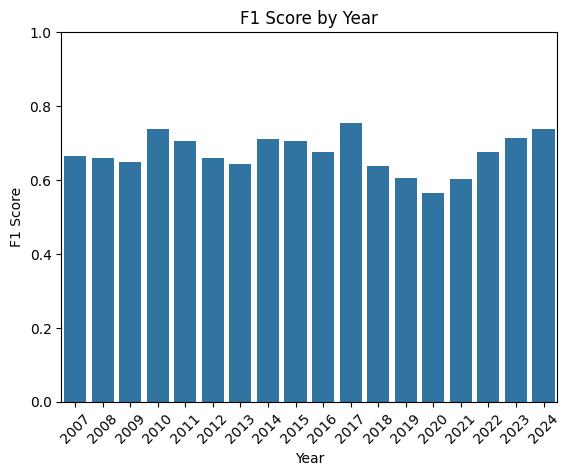

In [7]:
f1 = {year: d['f1_score'] for year, d in data.items()}

sns.barplot(x=list(f1.keys()), y=list(f1.values()))
plt.xlabel("Year")
plt.ylabel("F1 Score")
plt.title("F1 Score by Year")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

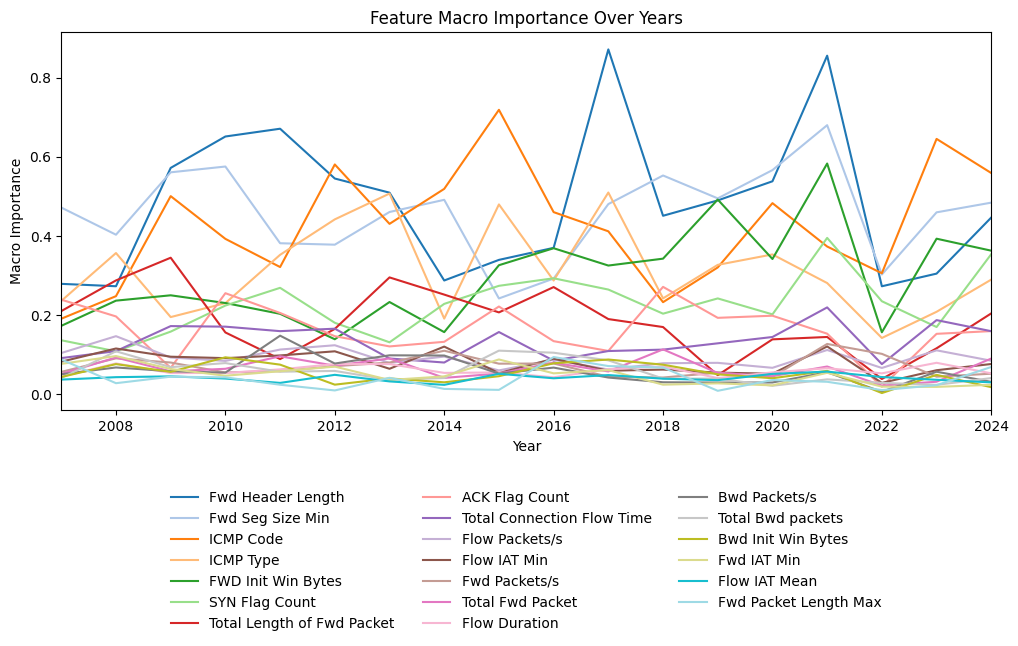

In [8]:
macro_importance = pl.DataFrame([
    {**row, "year": year}
    for year, d in data.items()
    for row in d["macro_importance"]
])

top20_macro = (macro_importance.group_by("feature")
    .agg(pl.col("macro_importance").mean().alias("mean_macro_importance"))
    .sort("mean_macro_importance", descending=True)
    .head(20).get_column("feature")).to_list()
tab20 = list(plt.cm.tab20.colors)
palette = {feat: tab20[i] for i, feat in enumerate(top20_macro)}

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=(
        macro_importance.filter(pl.col("feature").is_in(top20_macro))
    ).to_pandas(),
    x="year",
    y="macro_importance",
    hue="feature",
    hue_order=top20_macro,
    palette=palette,
)
plt.xlim(2007, 2024)
plt.xlabel("Year")
plt.ylabel("Macro Importance")
plt.title("Feature Macro Importance Over Years")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

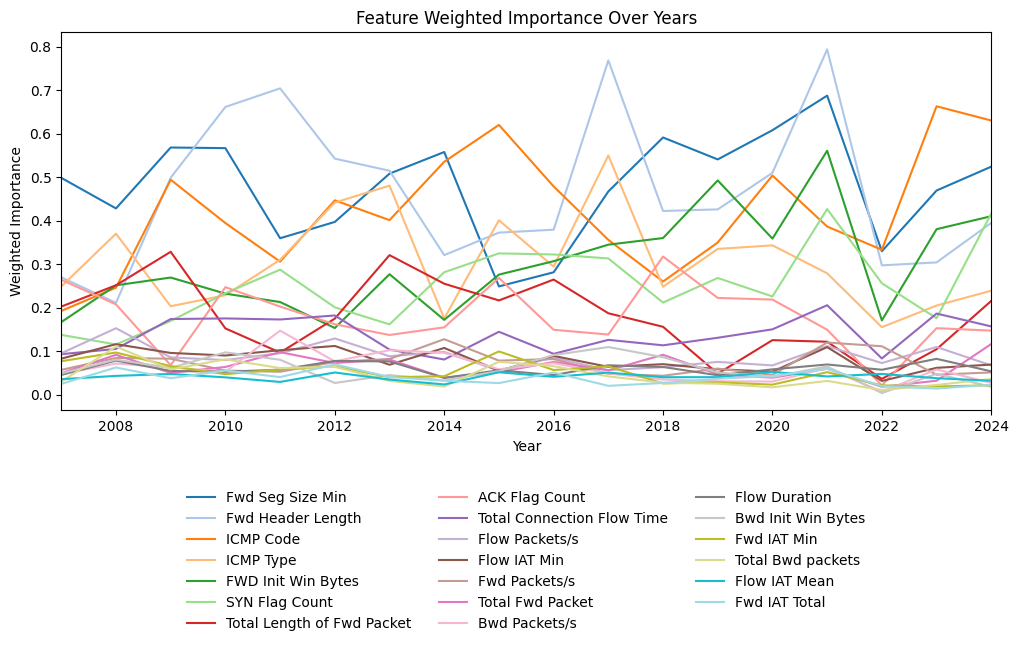

In [9]:
weighted_importance = pl.DataFrame([
    {**row, "year": year}
    for year, d in data.items()
    for row in d["weighted_importance"]
])

top20_weighted = (weighted_importance.group_by("feature")
    .agg(pl.col("weighted_importance").mean().alias("mean_weighted_importance"))
    .sort("mean_weighted_importance", descending=True)
    .head(20).get_column("feature")).to_list()
palette_w = {feat: tab20[i] for i, feat in enumerate(top20_weighted)}

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=(
        weighted_importance.filter(pl.col("feature").is_in(top20_weighted))
    ).to_pandas(),
    x="year",
    y="weighted_importance",
    hue="feature",
    hue_order=top20_weighted,
    palette=palette_w,
)
plt.xlim(2007, 2024)
plt.xlabel("Year")
plt.ylabel("Weighted Importance")
plt.title("Feature Weighted Importance Over Years")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

In [10]:
pd.DataFrame({
    'macro_importance': top20_macro,
    'weighted_importance': top20_weighted
})

,macro_importance,weighted_importance
0,Fwd Header Length,Fwd Seg Size Min
1,Fwd Seg Size Min,Fwd Header Length
2,ICMP Code,ICMP Code
3,ICMP Type,ICMP Type
4,FWD Init Win Bytes,FWD Init Win Bytes
5,SYN Flag Count,SYN Flag Count
6,Total Length of Fwd Packet,Total Length of Fwd Packet
7,ACK Flag Count,ACK Flag Count
8,Total Connection Flow Time,Total Connection Flow Time
9,Flow Packets/s,Flow Packets/s


In [15]:
def plot_class_feature_importance(data, features):
    per_class_importance = pl.DataFrame([
        {"year": year, "class": class_name, **features}
        for year, d in data.items()
        for class_name, features in d["per_class_importance"].items()
    ])

    df = per_class_importance.unpivot(
        index=["year", "class"],
        variable_name="feature",
        value_name="importance"
    ).filter(pl.col("feature").is_in(features))

    g = sns.FacetGrid(
        df.to_pandas(),
        col="class",
        col_wrap=3,  # Adjust for your number of classes
        sharey=False,
        height=4
    )
    g.map_dataframe(
        sns.lineplot,
        x="year",
        y="importance",
        hue="feature"
    )
    g.set(xlim=(2007, 2024), xticks=np.arange(2007, 2025, 1))
    for ax in g.axes.flat:
        ax.tick_params(axis="x", labelrotation=45)
    g.add_legend()
    g.set_axis_labels("Year", "Importance")
    g.fig.subplots_adjust(top=0.95)
    g.fig.suptitle("Feature Importance Over Years for Each Classs")
    plt.show()

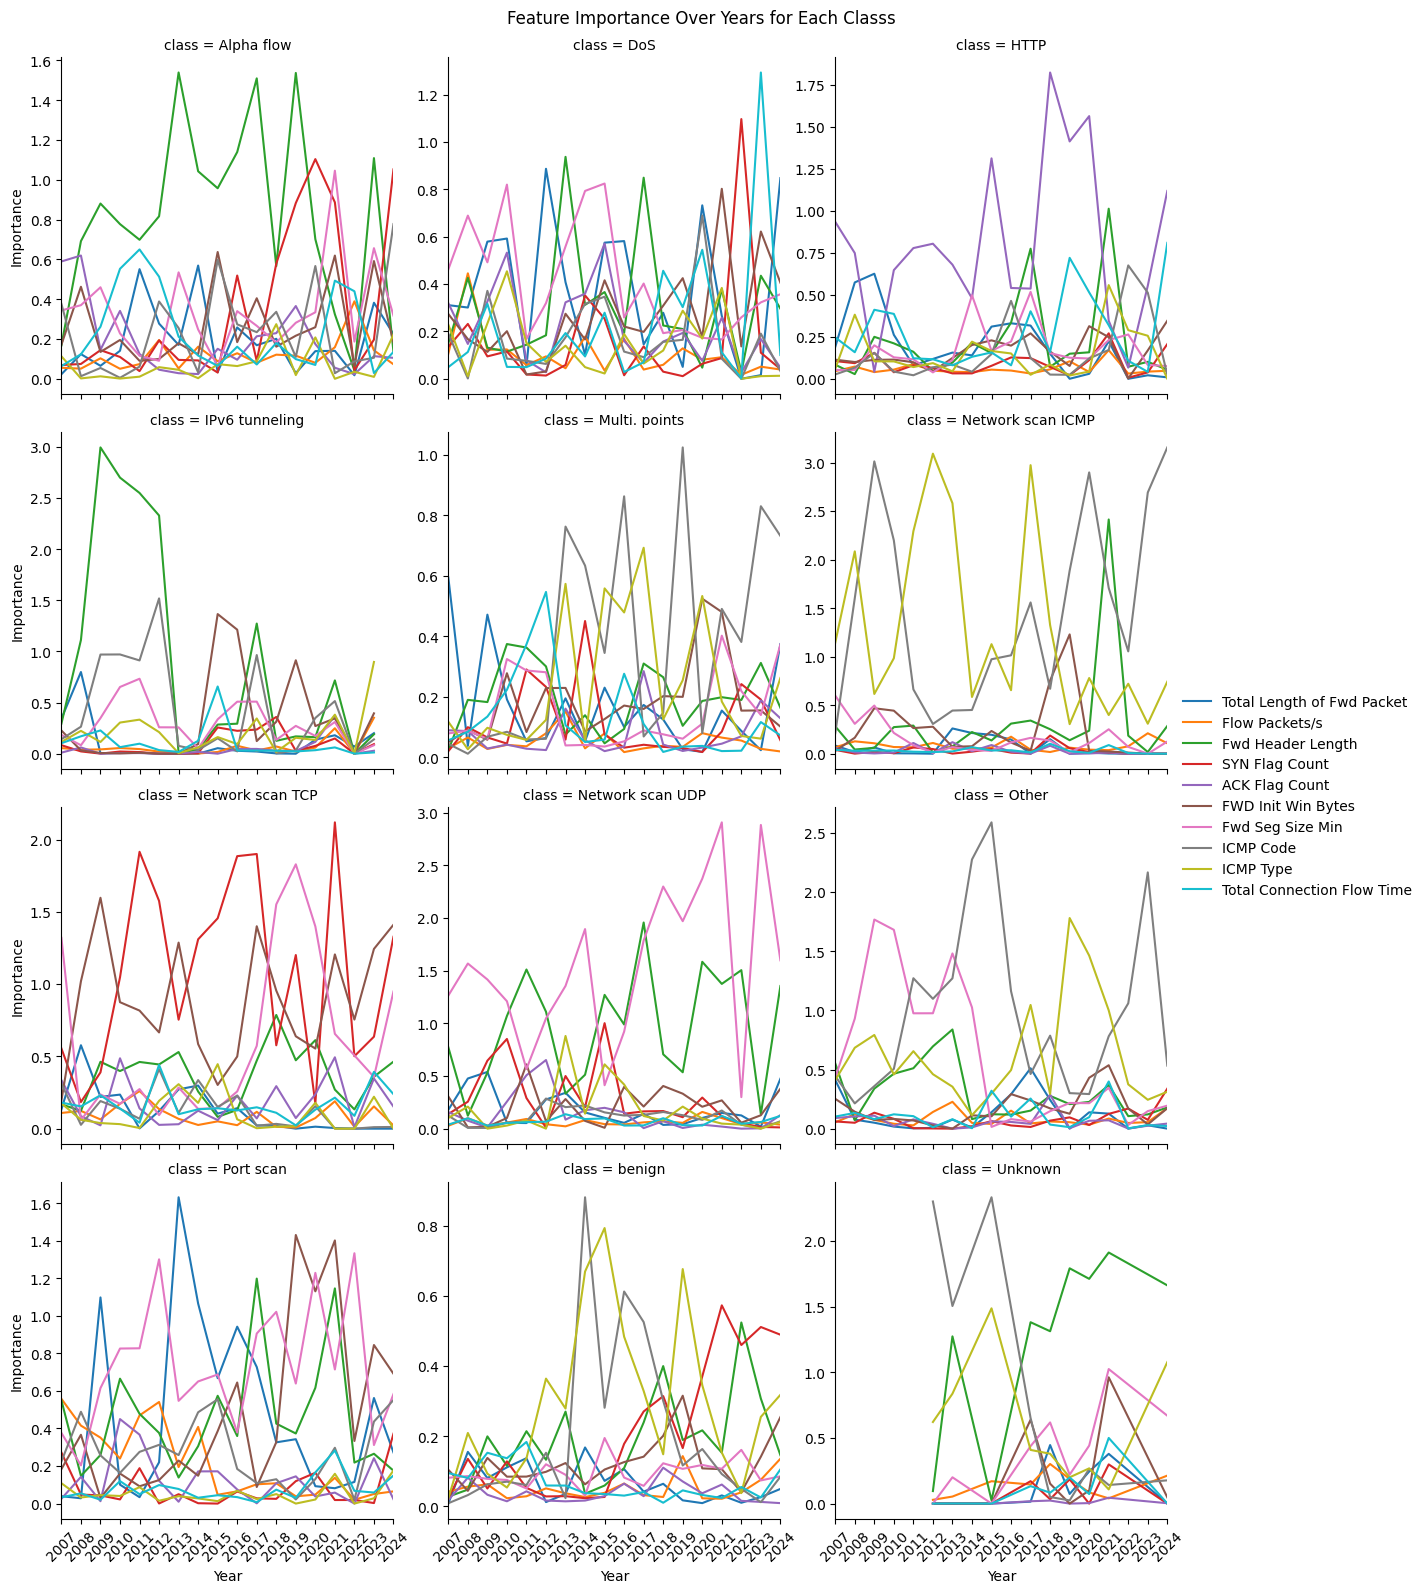

In [16]:
plot_class_feature_importance(
    data,
    (macro_importance.group_by("feature")
        .agg(pl.col("macro_importance").mean().alias("mean_macro_importance"))
        .sort("mean_macro_importance", descending=True)
        .head(10).get_column("feature")).to_list()
)